## Extracción

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/EdX994/Challenge-Telecom-X-parte-2/refs/heads/main/datos.csv'
df = pd.read_csv(url)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,Total.Day,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.20,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.01,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.34,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.17,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.97,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,1.90,55.15,742.90
7039,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.55,50.30,92.75
7041,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.30,67.85,4627.65


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

## 🛠️ Preparación de los Datos

In [3]:
df = df.drop(columns=['customerID'])

In [4]:
df_clean = df.copy()

In [5]:
cols_to_fix = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

In [6]:
for col in cols_to_fix:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

In [7]:
columnas_categoricas = [
    'Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
    'internet.InternetService',    'internet.OnlineSecurity',    'internet.OnlineBackup',    'internet.DeviceProtection',
    'internet.TechSupport',    'internet.StreamingTV',    'internet.StreamingMovies',    'account.Contract',    'account.PaperlessBilling',
    'account.PaymentMethod']

In [8]:
df_encoded = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=True)
display(df_encoded)

,customer.SeniorCitizen,customer.tenure,Total.Day,account.Charges.Monthly,account.Charges.Total,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.DeviceProtection_Yes,internet.TechSupport_Yes,internet.StreamingTV_Yes,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,2.20,65.60,593.30,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,0,9,2.01,59.90,542.40,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,2.34,73.90,280.85,True,True,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,1,13,3.17,98.00,1237.85,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,1,3,2.97,83.90,267.40,True,False,True,False,True,...,False,True,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,13,1.90,55.15,742.90,False,False,False,False,True,...,False,True,False,False,True,False,False,False,False,True
7039,0,22,2.84,85.10,1873.70,True,True,True,False,True,...,False,False,False,True,False,False,True,False,True,False
7040,0,2,1.55,50.30,92.75,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
7041,0,67,2.30,67.85,4627.65,False,True,True,True,True,...,True,True,False,True,False,True,False,False,False,True


In [9]:
df_encoded.isnull().sum()

,0
customer.SeniorCitizen,0
customer.tenure,0
Total.Day,11
account.Charges.Monthly,0
account.Charges.Total,11
Churn_Yes,0
customer.gender_Male,0
customer.Partner_Yes,0
customer.Dependents_Yes,0
phone.PhoneService_Yes,0


In [10]:
df_encoded = df_encoded.dropna(subset=['Total.Day', 'account.Charges.Total'])

In [11]:
df_encoded.isnull().sum()

,0
customer.SeniorCitizen,0
customer.tenure,0
Total.Day,0
account.Charges.Monthly,0
account.Charges.Total,0
Churn_Yes,0
customer.gender_Male,0
customer.Partner_Yes,0
customer.Dependents_Yes,0
phone.PhoneService_Yes,0


In [12]:
df_encoded['Churn_Yes'].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.734215
True,0.265785


## 🎯 Correlación y Selección de Variables

In [13]:
correlacion = df_encoded.corr()
correlacion['Churn_Yes']

,Churn_Yes
customer.SeniorCitizen,0.150541
customer.tenure,-0.354049
Total.Day,0.192030
account.Charges.Monthly,0.192858
account.Charges.Total,-0.199484
Churn_Yes,1.000000
customer.gender_Male,-0.008545
customer.Partner_Yes,-0.149982
customer.Dependents_Yes,-0.163128
phone.PhoneService_Yes,0.011691


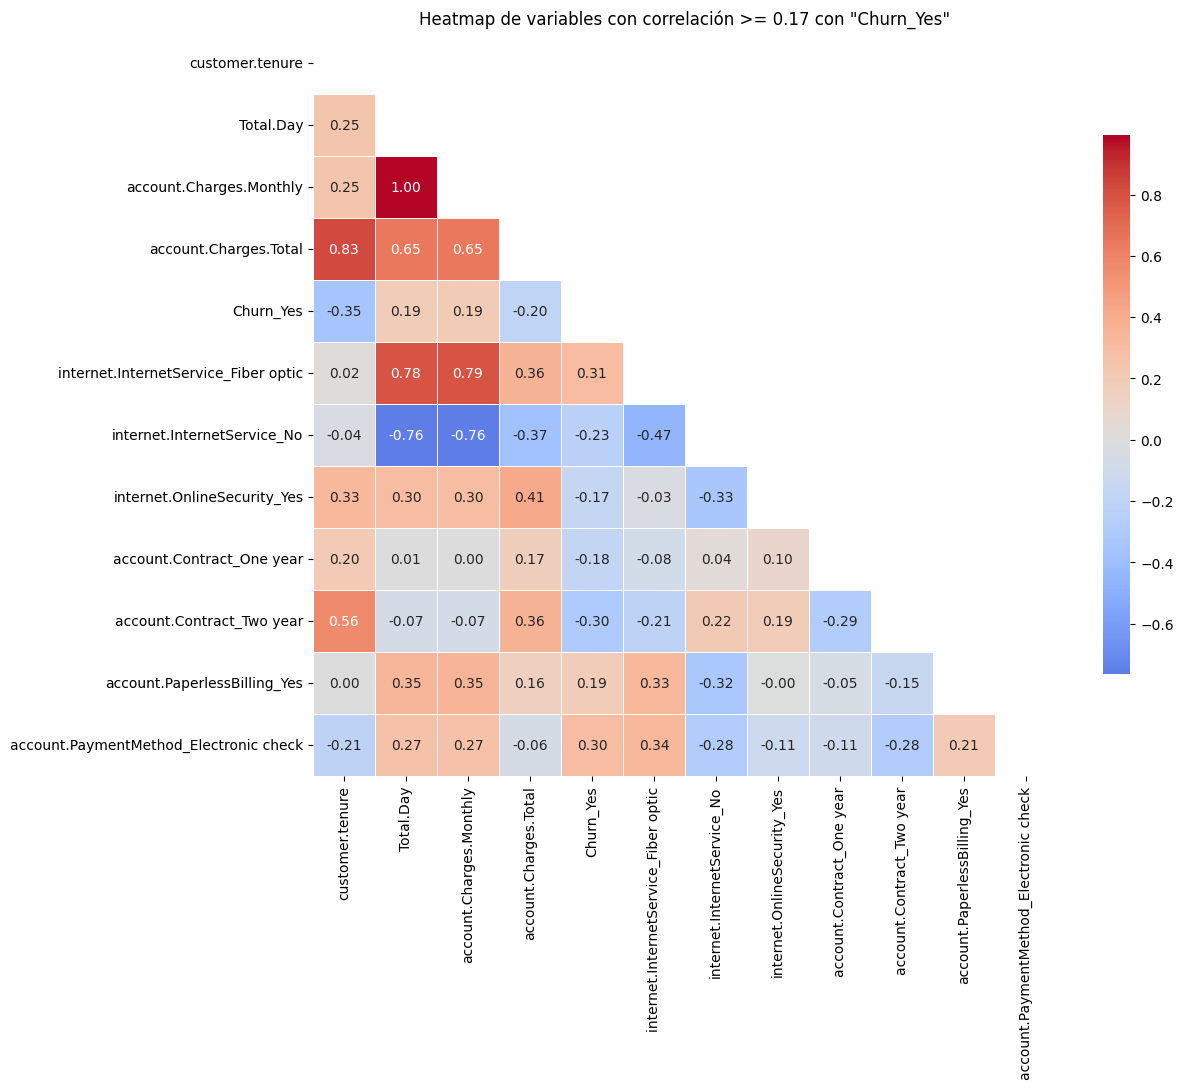

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

target = 'Churn_Yes'

limite = 0.17

var_relevantes = correlacion.index[abs(correlacion[target]) >= limite].tolist()

if target not in var_relevantes:
    var_relevantes.append(target)

correlacion_filtrada = correlacion.loc[var_relevantes, var_relevantes]

mascara = np.triu(np.ones_like(correlacion_filtrada, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(
    correlacion_filtrada,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    mask=mascara
)
plt.title(f'Heatmap de variables con correlación >= {limite} con "{target}"')
plt.show()

In [15]:
correlacion_filtrada['Churn_Yes']

,Churn_Yes
customer.tenure,-0.354049
Total.Day,0.192030
account.Charges.Monthly,0.192858
account.Charges.Total,-0.199484
Churn_Yes,1.000000
internet.InternetService_Fiber optic,0.307463
internet.InternetService_No,-0.227578
internet.OnlineSecurity_Yes,-0.171270
account.Contract_One year,-0.178225
account.Contract_Two year,-0.301552


**Análisis dirigido**

Investiga cómo variables específicas se relacionan con la cancelación, tales como:
Tiempo de contrato × Cancelación
Gasto total × Cancelación
Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

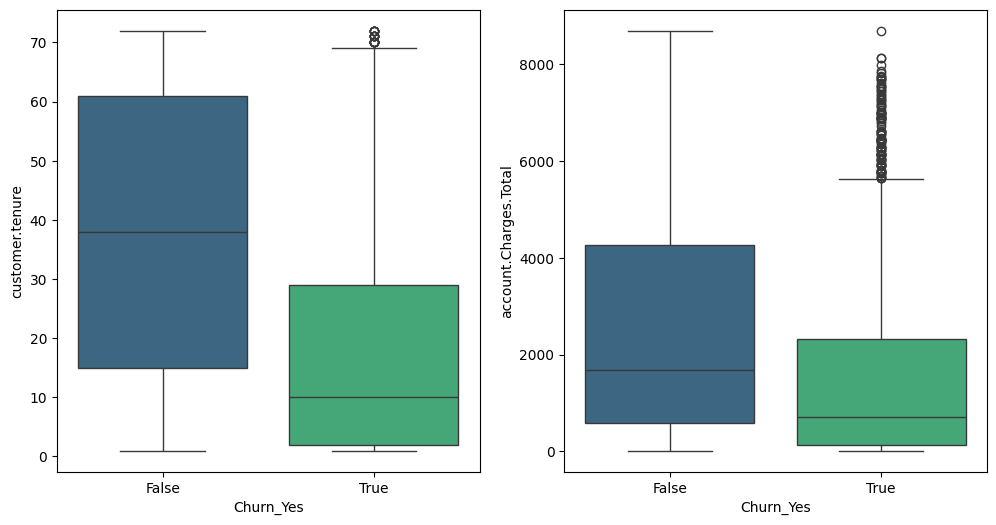

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(x='Churn_Yes', y='customer.tenure', data=df_encoded, ax=ax[0], hue='Churn_Yes', palette='viridis', legend=False)
sns.boxplot(x='Churn_Yes', y='account.Charges.Total', data=df_encoded, ax=ax[1], hue='Churn_Yes', palette='viridis', legend=False)
plt.show()

##🤖 Modelado Predictivo

### Separación de datos

In [17]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [19]:
y_train.value_counts()

,count
Churn_Yes,
False,3614
True,1308


### Balanceamiento de clases

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=25)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

In [21]:
y_train_balanceado.value_counts()

,count
Churn_Yes,
True,3614
False,3614


### Modelo RandomForest

In [22]:
from sklearn.ensemble import RandomForestClassifier
random_Forest = RandomForestClassifier(max_depth=3, random_state=25)
random_Forest.fit(X_train_balanceado, y_train_balanceado)
random_Forest.score(X_test, y_test)

0.7563981042654029

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_prev = random_Forest.predict(X_test)

print(f'La Exactitud (Accuracy) del modelo Random Forest es: {accuracy_score(y_test, y_prev):.4f}')
print(f'La Precisión (Precision) del modelo Random Forest es: {precision_score(y_test, y_prev):.4f}')
print(f'La Sensibilidad (Recall) del modelo Random Forest es: {recall_score(y_test, y_prev):.4f}')
print(f'El F1-Score del modelo Random Forest es: {f1_score(y_test, y_prev):.4f}')

La Exactitud (Accuracy) del modelo Random Forest es: 0.7564
La Precisión (Precision) del modelo Random Forest es: 0.5326
La Sensibilidad (Recall) del modelo Random Forest es: 0.6845
El F1-Score del modelo Random Forest es: 0.5991


### Modelo de Regresión Logística

#### Normalizacion de los datos para utilizar modelo de regresión

La normalización asegura que los modelos no estén sesgados por la magnitud de las variables y permite que cada característica tenga una influencia equitativa en el proceso de modelado. Esto mejora la eficacia y eficiencia de los algoritmos basados en distancia y optimización, resultando en un mejor rendimiento del modelo.

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanceado)
X_test_scaled = scaler.transform(X_test)

#### Ejecución del modelo

In [27]:
from sklearn.linear_model import LogisticRegression

regresion_logistica = LogisticRegression(max_iter=1000)
regresion_logistica.fit(X_train_scaled, y_train_balanceado)
print("Precisión Regresión Logística:", regresion_logistica.score(X_test_scaled, y_test))

Precisión Regresión Logística: 0.7758293838862559


In [28]:
y_pred = regresion_logistica.predict(X_test_scaled)
print(f'La Exactitud (Accuracy) del modelo de Regresión Logística es: {accuracy_score(y_test, y_pred):.4f}')
print(f'La Precisión (Precision) del modelo de Regresión Logística es: {precision_score(y_test, y_pred):.4f}')
print(f'La Sensibilidad (Recall) del modelo de Regresión Logística es: {recall_score(y_test, y_pred):.4f}')
print(f'El F1-Score del modelo de Regresión Logística es: {f1_score(y_test, y_pred):.4f}')

La Exactitud (Accuracy) del modelo de Regresión Logística es: 0.7758
La Precisión (Precision) del modelo de Regresión Logística es: 0.5726
La Sensibilidad (Recall) del modelo de Regresión Logística es: 0.6185
El F1-Score del modelo de Regresión Logística es: 0.5947


### Matriz de Confusión

In [29]:
from sklearn.metrics import confusion_matrix
y_previsto = random_Forest.predict(X_test)
matriz_confusion = confusion_matrix(y_test,y_previsto)
matriz_confusion


array([[1212,  337],
       [ 177,  384]])

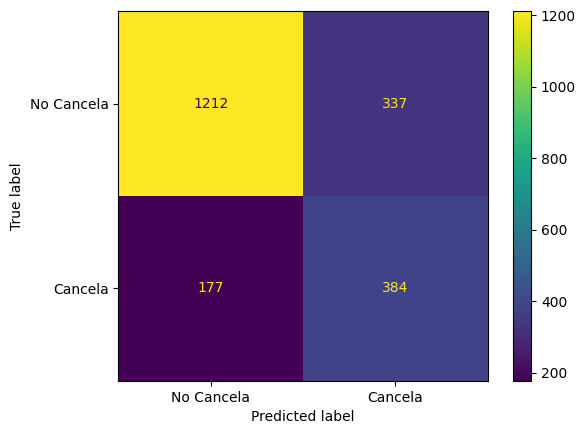

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['No Cancela','Cancela'])
visualizacion.plot();

In [31]:
from sklearn.metrics import confusion_matrix
y_previsto = regresion_logistica.predict(X_test)
matriz_confusion2 = confusion_matrix(y_test,y_previsto)
matriz_confusion2


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([[ 185, 1364],
       [ 226,  335]])

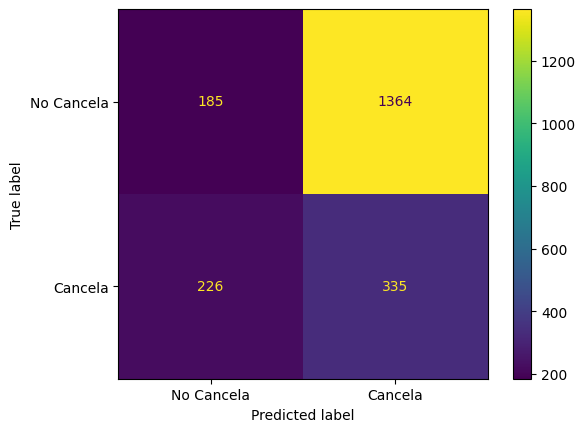

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacion2 = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion2, display_labels=['No Cancela','Cancela'])
visualizacion2.plot();

### Curva de ROC

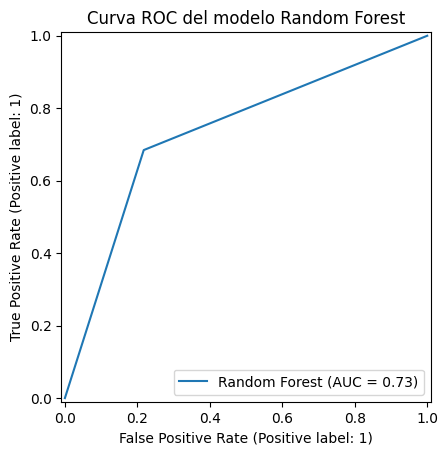

In [39]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prev, name='Random Forest')
plt.title('Curva ROC del modelo Random Forest');

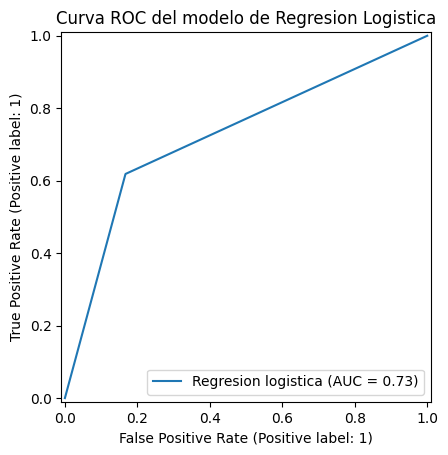

In [40]:
RocCurveDisplay.from_predictions(y_test, y_pred, name='Regresion logistica')
plt.title('Curva ROC del modelo de Regresion Logistica');

### Informe de métricas

In [35]:
from sklearn.metrics import classification_report
print('Informe de métricas del modelo Random Forest: \n')
print(classification_report(y_test, y_prev))

Informe de métricas del modelo Random Forest: 

              precision    recall  f1-score   support

       False       0.87      0.78      0.83      1549
        True       0.53      0.68      0.60       561

    accuracy                           0.76      2110
   macro avg       0.70      0.73      0.71      2110
weighted avg       0.78      0.76      0.76      2110



In [36]:
print('Informe de métricas del modelo de Regresión Logística: \n')
print(classification_report(y_test, y_pred))

Informe de métricas del modelo de Regresión Logística: 

              precision    recall  f1-score   support

       False       0.86      0.83      0.85      1549
        True       0.57      0.62      0.59       561

    accuracy                           0.78      2110
   macro avg       0.72      0.73      0.72      2110
weighted avg       0.78      0.78      0.78      2110



### 📋 Interpretación y Conclusiones

#### Análisis de la Importancia de las Variables




In [ ]:
importancia = random_Forest.feature_importances_

In [ ]:
feature_importances = pd.DataFrame({'Feature' : X.columns, 'Importancia' : (importancia*100).round(2)}).sort_values('Importancia', ascending=False)
feature_importances

,Feature,Importancia
23,account.PaymentMethod_Electronic check,24.61
11,internet.InternetService_Fiber optic,18.13
1,customer.tenure,15.47
20,account.Contract_Two year,9.41
21,account.PaperlessBilling_Yes,9.34
4,account.Charges.Total,6.94
3,account.Charges.Monthly,4.43
2,Total.Day,3.22
12,internet.InternetService_No,2.73
19,account.Contract_One year,1.24


#### Conclusiones

Entre los hallazgos principales, resaltan que:

- Los clientes recientes son más propensos a dejar el servicio.

- Cuotas mensuales elevadas están vinculadas a un mayor índice de abandono.

- Los usuarios con contratos de pago mensual muestran mayor tendencia a abandonar.

- El uso del cheque electrónico como método de pago se relaciona con una mayor evasión.

- Entre los servicios ofrecidos, la fibra óptica presenta la mayor probabilidad de deserción.


A partir de los resultados obtenidos, se proponen las siguientes estrategias:

- Implementar programas de fidelización para nuevos clientes.

- Ofrecer descuentos a los clientes con cargos mensuales elevados o algún beneficio por antiguendad.

- Incentivar los contratos a largo plazo con beneficios exclusivos.

- Desincentivar el uso de cheque electrónico como método de pago, ofreciendo recompensas al utilizar otros medios de pago.

- Evaluar la calidad precio del servicio de fibra óptica y ajustar de ser necesario.

#### Modelos predictivos utilizados

- **Exactitud:** El modelo de Regresión Logística tiene una exactitud general ligeramente mayor (0.7758) en comparación con el modelo Random Forest (0.7564). Esto significa que predice correctamente un porcentaje ligeramente mayor de casos, tanto de abandono como de no abandono.

- **Precisión:** La Regresión Logística tiene una precisión más alta para predecir el abandono (0.57) que Random Forest (0.53). Esto significa que cuando la Regresión Logística predice que un cliente abandonará, es correcta con más frecuencia que Random Forest.

- **Sensibilidad:** Random Forest tiene una sensibilidad más alta para predecir el abandono (0.68) que la Regresión Logística (0.62). Esto significa que Random Forest es mejor para identificar a los clientes que realmente abandonan (menos falsos negativos).

- **F1-Score:** Los F1-scores son muy similares (0.60 para Random Forest, 0.59 para Regresión Logística). El F1-score es la media armónica de la precisión y la sensibilidad, proporcionando una medida equilibrada del rendimiento del modelo.

- **ROC AUC:** Ambos modelos tienen el mismo puntaje ROC AUC de 0.73, lo que indica una capacidad discriminatoria general similar.

Por lo tanto, basándonos en estas métricas, el modelo de Regresión Logística parece ser ligeramente más efectivo para este conjunto de datos específico y criterios de evaluación.